In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

In [2]:
len(train_data)

60000

In [3]:
len(test_data)

10000

```bash
pip uninstall torch torchvision
pip install "torch==2.8.0" "torchvision==0.23.0"
```

Forma Immagine: torch.Size([1, 28, 28])


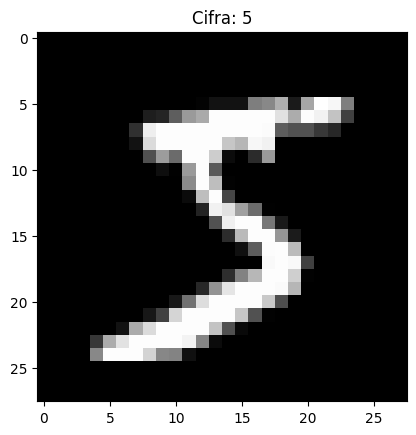

In [4]:
# import numpy as np
image, label = train_data[0]

print(f"Forma Immagine: {image.shape}")

plt.figure()
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Cifra: {label}")
plt.show()

In [5]:
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size

train_dataset, val_dataset = random_split(train_data, [train_size, val_size])

In [6]:
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

images_batch, labels_batch = next(iter(train_loader))
images_batch.shape

torch.Size([64, 1, 28, 28])

In [7]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        
        x = self.flatten(x)

        # Layer 1
        x = self.fc1(x)
        x = self.relu(x)

        # Layer 1
        x = self.fc2(x)
        x = self.relu(x)

        # Output
        x = self.fc3(x)

        return x
    
model = SimpleMLP()
print(model)

total_parameters = sum(p.numel() for p in model.parameters())
total_parameters

SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


109386

In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [10]:
epoch_number = 5

for epoch in range(epoch_number):
    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch: {epoch}, Loss della batch: {loss.item():.4f}")


Epoch: 0, Loss della batch: 0.0940
Epoch: 1, Loss della batch: 0.1484
Epoch: 2, Loss della batch: 0.1816
Epoch: 3, Loss della batch: 0.0304
Epoch: 4, Loss della batch: 0.0260


1: tensor([[  0.2463,   4.4035,  12.7561,   6.0763, -14.9677,   0.1542,   2.1681,
          -4.9167,   4.5363, -11.0943]], device='cuda:0',
       grad_fn=<AddmmBackward0>)
2: <class 'torch.Tensor'>
3: <class 'int'>
Predizione: 2


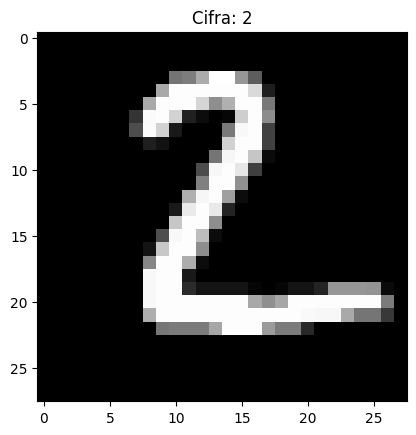

In [11]:
image, label = test_data[1]
output = model(image.unsqueeze(0).to(device))
print(f"1: {output}")
print(f"2: {type(output.argmax())}")
print(f"3: {type(output.argmax().item())}")
prediction = output.argmax().item()

print(f"Predizione: {prediction}")

plt.figure()
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Cifra: {label}")
plt.show()